# Questions 2 & 3: Logistic Regression and Hyperparameter Tuning – IBM HR Employee Attrition

**Dataset chosen (Q2 asks for ONE):** [IBM HR Analytics Employee Attrition](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) – 1,470 employees, 35 columns. Target: `Attrition` (Yes = employee left). Question 3 re-uses the same dataset.

**Part A – Question 2:** justification → EDA → preprocessing → Logistic Regression → evaluation → odds ratios → class imbalance
**Part B – Question 3:** parameters vs hyperparameters → baseline → GridSearchCV → RandomizedSearchCV → comparison → cost/performance trade-offs

In [1]:
import os, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import loguniform
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score,
                             f1_score, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42

# PART A – Question 2: Logistic Regression for Employee Attrition

## 1. Why Logistic Regression is suitable
- **Binary outcome:** `Attrition` ∈ {Yes, No}. Linear regression could predict values outside [0, 1] and assumes a continuous, homoscedastic response; logistic regression models the **probability** through the sigmoid: $P(y=1\\mid x)=\\frac{1}{1+e^{-(\\beta_0+\\beta^\\top x)}}$.
- **Interpretability:** each coefficient is a change in **log-odds**; $e^{\\beta}$ is an **odds ratio** that HR can act on (e.g. "working overtime multiplies the odds of leaving by ×k").
- **Probabilistic output:** gives a risk score per employee, so the decision threshold can be tuned to the cost of missing a leaver vs. a false alarm.
- **Well-behaved on modest data:** only 1,470 rows – a simple, regularisable model is less prone to over-fitting than complex models, and provides a strong baseline.
- **Assumptions are mild:** binary target, independent observations, little multicollinearity, and a linear relationship between predictors and the *log-odds* (no normality or constant-variance requirement).

## 2. Load data & EDA

In [2]:
URL = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
path = next((p for p in ["WA_Fn-UseC_-HR-Employee-Attrition.csv", "data/WA_Fn-UseC_-HR-Employee-Attrition.csv"] if os.path.exists(p)), URL)
df = pd.read_csv(path, encoding="utf-8-sig")
print("Loaded from:", path, "| shape:", df.shape)
df.head()

Loaded from: WA_Fn-UseC_-HR-Employee-Attrition.csv | shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()
print("\nMissing values:", df.isna().sum().sum(), "| duplicates:", df.duplicated().sum())
nun = df.nunique(); print("Constant columns:", nun[nun == 1].index.tolist())
print("Unique-ID column EmployeeNumber unique:", df.EmployeeNumber.is_unique)

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

Attrition
No     1233
Yes     237
Name: count, dtype: int64 
 Attrition
No     83.9%
Yes    16.1%
Name: count, dtype: str


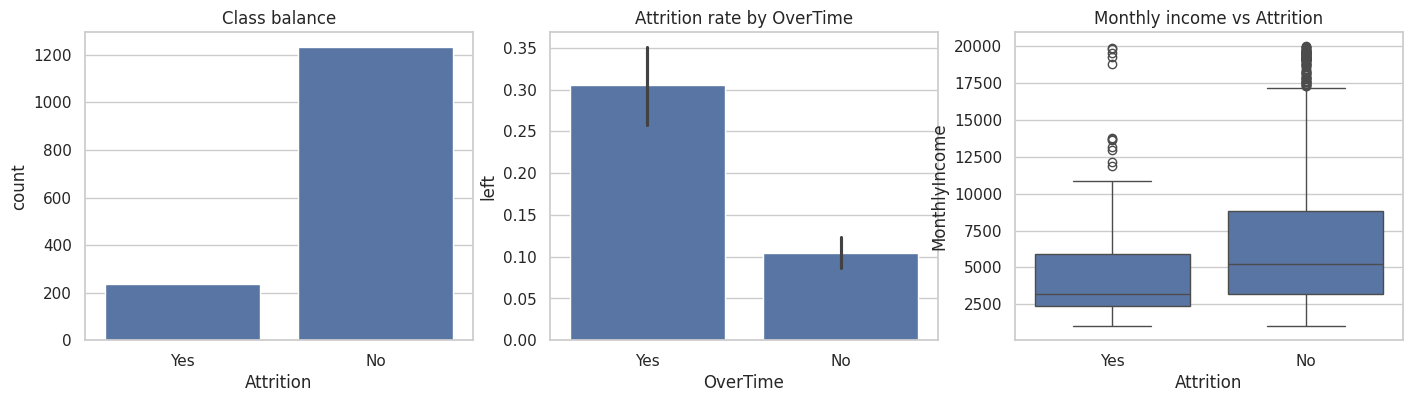

In [4]:
vc = df.Attrition.value_counts(); print(vc, "\n", (vc / len(df) * 100).round(1).astype(str) + "%")
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
sns.countplot(data=df, x="Attrition", ax=ax[0]); ax[0].set_title("Class balance")
sns.barplot(data=df.assign(left=(df.Attrition == "Yes")), x="OverTime", y="left", ax=ax[1]); ax[1].set_title("Attrition rate by OverTime")
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", ax=ax[2]); ax[2].set_title("Monthly income vs Attrition")
plt.show()

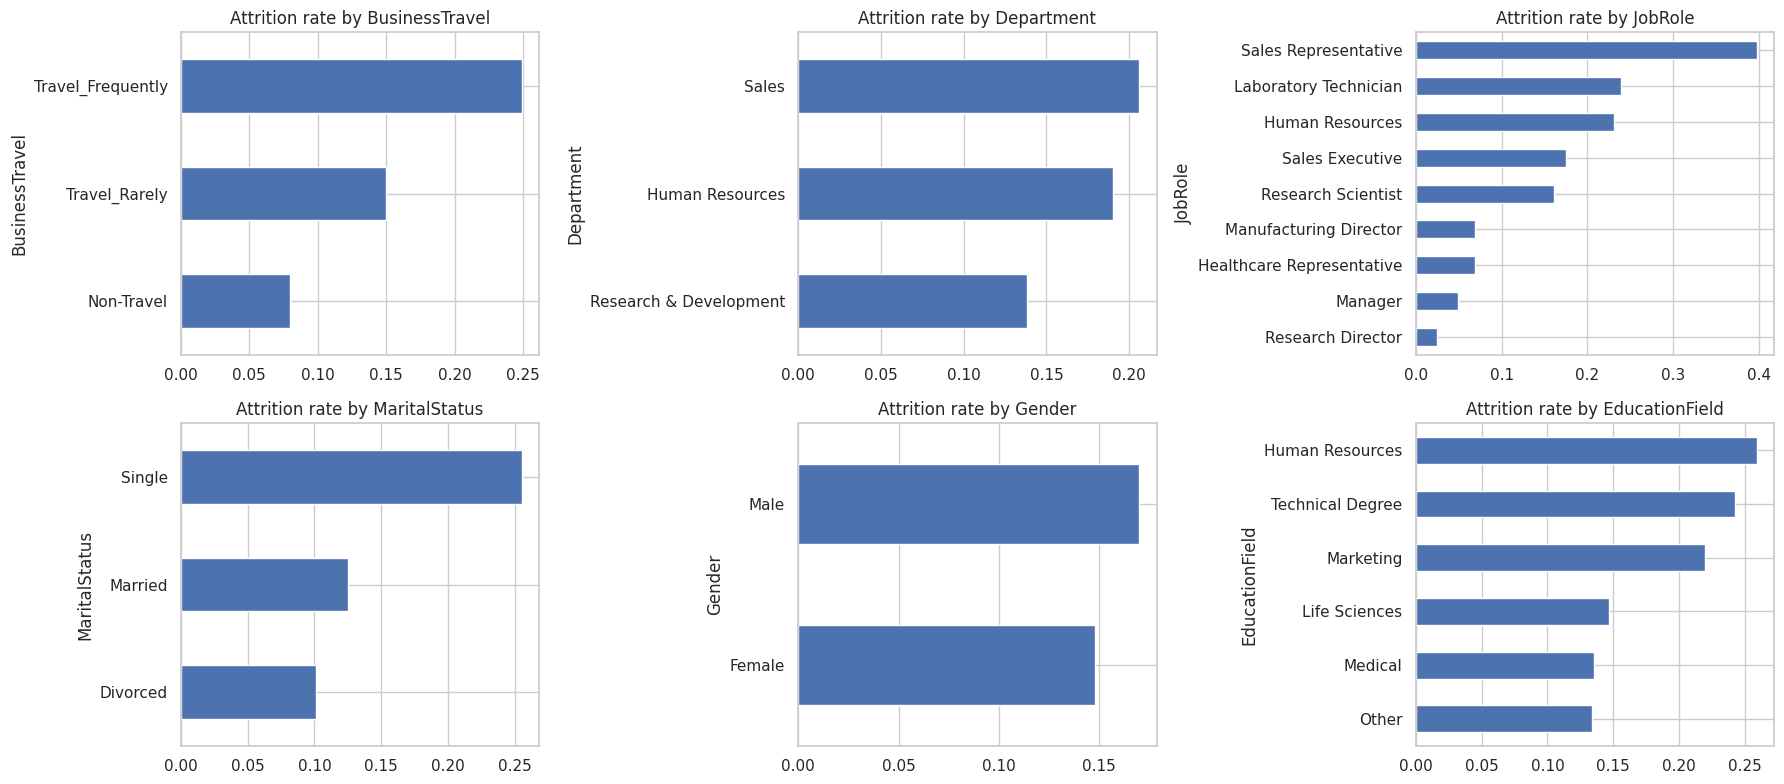

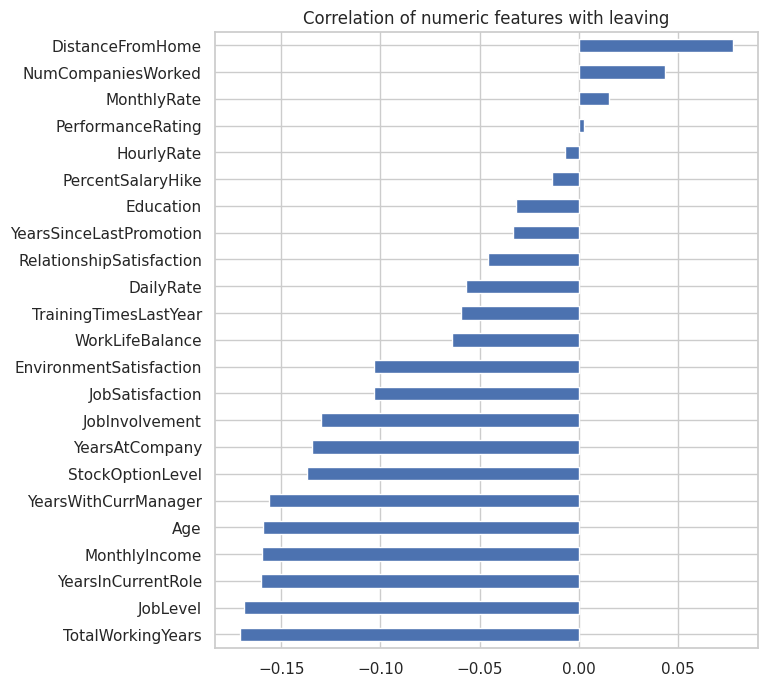

In [5]:
cat_cols_eda = ["BusinessTravel", "Department", "JobRole", "MaritalStatus", "Gender", "EducationField"]
fig, ax = plt.subplots(2, 3, figsize=(18, 8))
for a, c in zip(ax.ravel(), cat_cols_eda):
    rate = df.groupby(c).Attrition.apply(lambda s: (s == "Yes").mean()).sort_values()
    rate.plot.barh(ax=a); a.set_title(f"Attrition rate by {c}"); a.set_xlabel("")
plt.tight_layout(); plt.show()
num = df.select_dtypes("number").drop(columns=["EmployeeCount", "StandardHours", "EmployeeNumber"])
corr = num.assign(target=(df.Attrition == "Yes").astype(int)).corr()["target"].drop("target").sort_values()
corr.plot.barh(figsize=(7, 8), title="Correlation of numeric features with leaving"); plt.show()

**Observations**
- **Imbalanced target:** only ≈ 16% of employees left (237 vs 1,233).
- No missing values or duplicates; `EmployeeCount`, `StandardHours`, `Over18` are constants and `EmployeeNumber` is an ID → **dropped** (no information).
- Attrition is higher for employees who work **overtime**, **travel frequently**, are **single**, in **Sales** roles (e.g. Sales Representative), and lower for those with higher income, job level, tenure and stock options.

## 3. Preprocessing
| Step | Decision |
|---|---|
| Missing values | None present, but a `SimpleImputer` (median / most-frequent) is kept in the pipeline so the pipeline is robust to new data |
| Encoding | Target → 0/1. Binary `Gender`, `OverTime` → 0/1. Nominal (`BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus`) → **one-hot** (drop first to avoid the dummy trap). Ordinal survey scores (1–4/1–5) are already numeric and kept as-is |
| Scaling | `StandardScaler` on numeric features – required because logistic regression uses regularisation/gradient-based solvers and so coefficients become comparable |
| Leakage control | Split first (stratified 80/20); imputer/encoder/scaler live in a `Pipeline` and are fit on training folds only |

In [6]:
data = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]).copy()
y = (data.pop("Attrition") == "Yes").astype(int)
X = data.copy()
X["Gender"] = (X["Gender"] == "Male").astype(int)
X["OverTime"] = (X["OverTime"] == "Yes").astype(int)

cat_cols = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"]
num_cols = [c for c in X.columns if c not in cat_cols]
print(len(num_cols), "numeric/binary features,", len(cat_cols), "categorical features")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "attrition rate %.3f" % y_train.mean(), "| Test:", X_test.shape, "attrition rate %.3f" % y_test.mean())

def make_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))]), cat_cols),
    ])
def make_model(**kw):
    return Pipeline([("prep", make_preprocessor()), ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **kw))])

25 numeric/binary features, 5 categorical features
Train: (1176, 30) attrition rate 0.162 | Test: (294, 30) attrition rate 0.160


## 4. Train the Logistic Regression classifier

In [7]:
model = make_model().fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred = model.predict(X_test)
print("Train accuracy: %.3f | Test accuracy: %.3f" % (model.score(X_train, y_train), model.score(X_test, y_test)))

Train accuracy: 0.902 | Test accuracy: 0.861


## 5. Evaluation
- **Confusion matrix** – TP/FP/TN/FN counts.
- **Precision** = TP/(TP+FP) – of those flagged as leavers, how many really leave.
- **Recall** = TP/(TP+FN) – of the real leavers, how many we catch.
- **F1** – harmonic mean of precision and recall.
- **AUC** – probability that a random leaver gets a higher score than a random stayer (threshold-independent).
**Accuracy is misleading** with 84% stayers, so we compare with a "predict everyone stays" baseline.

In [8]:
def evaluate(y_true, y_pred, y_proba, name):
    return {"Model": name, "Accuracy": accuracy_score(y_true, y_pred), "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred), "F1": f1_score(y_true, y_pred), "AUC": roc_auc_score(y_true, y_proba)}

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
scores = [evaluate(y_test, dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1], "Always predict 'stay'"),
          evaluate(y_test, pred, proba, "Logistic Regression (threshold 0.5)")]
pd.DataFrame(scores).set_index("Model")

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Always predict 'stay',0.8401,0.0000,0.0000,0.0000,0.5000
Logistic Regression (threshold 0.5),0.8605,0.6154,0.3404,0.4384,0.8117


              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



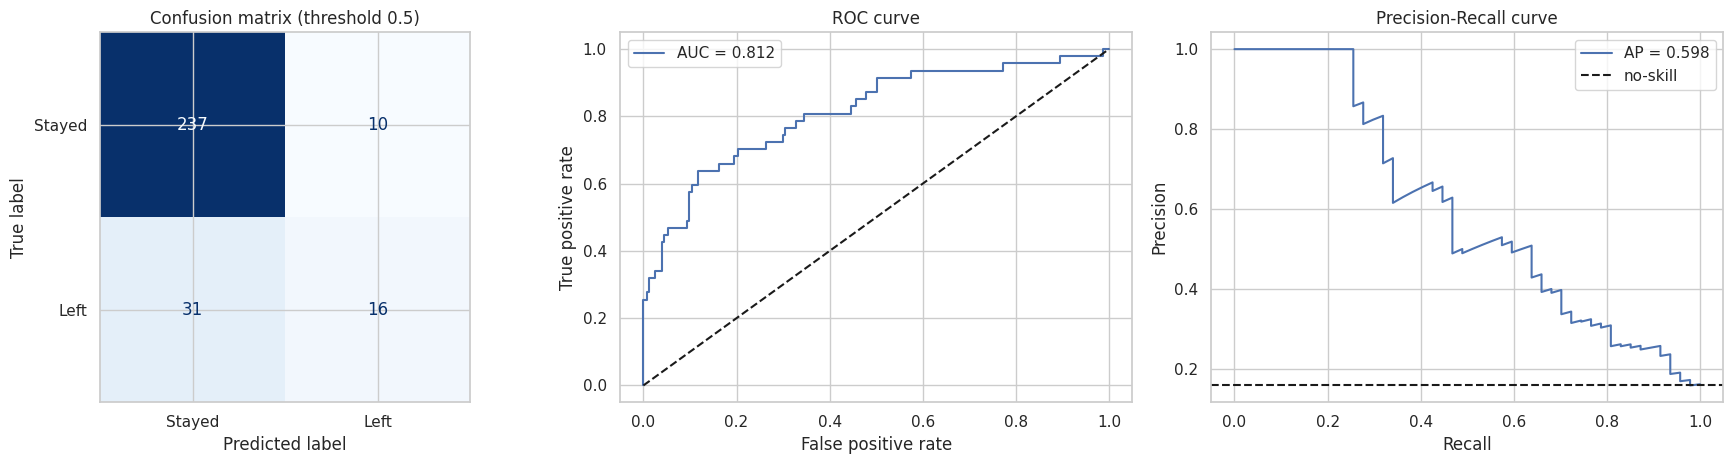

In [9]:
print(classification_report(y_test, pred, target_names=["Stayed", "Left"]))
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Stayed", "Left"]).plot(ax=ax[0], cmap="Blues", colorbar=False); ax[0].set_title("Confusion matrix (threshold 0.5)")
fpr, tpr, _ = roc_curve(y_test, proba); ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}"); ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve"); ax[1].legend()
p, r, _ = precision_recall_curve(y_test, proba); ax[2].plot(r, p, label=f"AP = {average_precision_score(y_test, proba):.3f}"); ax[2].axhline(y_test.mean(), color="k", ls="--", label="no-skill")
ax[2].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve"); ax[2].legend()
plt.tight_layout(); plt.show()

**Reading the results:** the model ranks employees by risk well (**AUC ≈ 0.81**; the trivial baseline is 0.50). Its accuracy (≈ 86%) is only slightly above the "everyone stays" baseline (84%) – which is exactly why accuracy alone is not informative. At the default 0.5 threshold the model is **conservative**: precision is moderate (≈ 0.62) but **recall is only ≈ 0.34** – it misses about two out of three real leavers. Since losing an employee is usually costlier than a wasted retention conversation, recall deserves more weight – see Section 7.

## 6. Interpreting coefficients as odds ratios
For feature $x_j$ the **odds ratio** is $OR_j = e^{\\beta_j}$:
- OR > 1 → increases the odds of leaving; OR < 1 → decreases them; OR = 1 → no effect.
- Numeric features are standardised, so their OR is the change in odds per **+1 standard deviation**; dummy variables are relative to the dropped reference category; `OverTime` and `Gender` are 0/1 so OR is Yes vs No (Male vs Female).

,feature,coef (log-odds),odds_ratio,pct_change_in_odds
0,BusinessTravel_Travel_Frequently,1.5567,4.7434,374.3365
1,JobRole_Laboratory Technician,1.3144,3.7226,272.2624
2,JobRole_Sales Representative,0.9482,2.5810,158.1002
3,EducationField_Other,-0.8880,0.4115,-58.8528
4,JobRole_Research Director,-0.8518,0.4267,-57.3336
5,OverTime,0.8449,2.3276,132.7642
6,MaritalStatus_Single,0.6952,2.0042,100.4202
7,BusinessTravel_Travel_Rarely,0.6826,1.9790,97.9006
8,Department_Research & Development,-0.5752,0.5626,-43.7396
9,TotalWorkingYears,-0.5296,0.5889,-41.1148


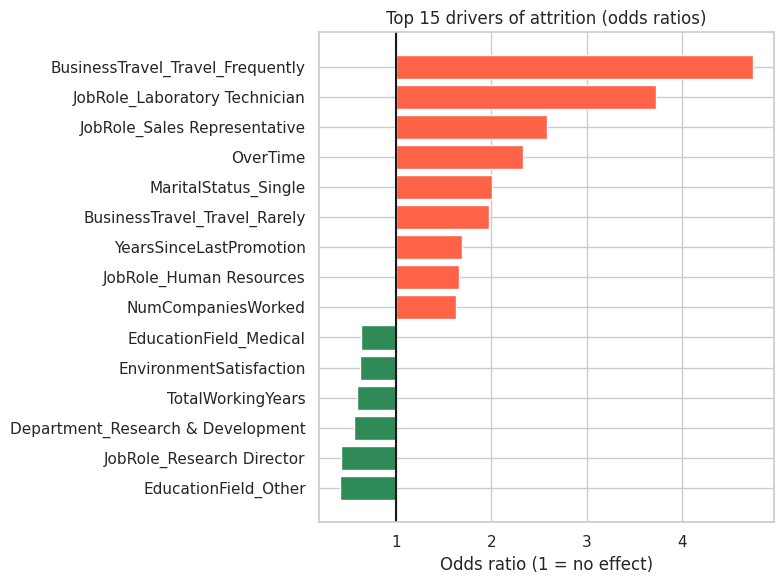

In [10]:
names = model.named_steps["prep"].get_feature_names_out()
names = [n.split("__", 1)[1] for n in names]
coefs = model.named_steps["clf"].coef_[0]
orr = pd.DataFrame({"feature": names, "coef (log-odds)": coefs, "odds_ratio": np.exp(coefs), "pct_change_in_odds": (np.exp(coefs) - 1) * 100})
orr = orr.reindex(orr["coef (log-odds)"].abs().sort_values(ascending=False).index).reset_index(drop=True)
display(orr.head(15))
top = orr.head(15).sort_values("odds_ratio")
plt.figure(figsize=(8, 6)); plt.barh(top.feature, top.odds_ratio - 1, left=1, color=np.where(top.odds_ratio > 1, "tomato", "seagreen"))
plt.axvline(1, color="k"); plt.xlabel("Odds ratio (1 = no effect)"); plt.title("Top 15 drivers of attrition (odds ratios)"); plt.tight_layout(); plt.show()

**Business interpretation** (holding all other features constant; dummy variables are compared with the dropped reference category – *Non-Travel*, *Divorced*, *Healthcare Representative*, etc.):
- **`BusinessTravel_Travel_Frequently`** is the largest effect (OR ≈ 4.7): frequent travellers have ~4–5× the odds of leaving versus non-travellers.
- **Job role matters:** relative to Healthcare Representatives, **Laboratory Technicians (OR ≈ 3.7)** and **Sales Representatives (OR ≈ 2.6)** are far more likely to leave.
- **`OverTime` = Yes** multiplies the odds of leaving by ≈ **2.3** and **`MaritalStatus_Single`** by ≈ **2.0** (vs. divorced).
- **`YearsSinceLastPromotion`** (OR ≈ 1.7 per SD), **`NumCompaniesWorked`** (≈ 1.6) and **`DistanceFromHome`** (≈ 1.5) raise the odds: stalled careers, job-hoppers and long commutes.
- **Protective factors (OR < 1, per +1 SD):** `TotalWorkingYears` (≈ 0.59), `EnvironmentSatisfaction` (≈ 0.63), `JobSatisfaction` (≈ 0.66), `YearsWithCurrManager` (≈ 0.67), `JobInvolvement` (≈ 0.70), `StockOptionLevel` (≈ 0.73) and `WorkLifeBalance` (≈ 0.74) – satisfied, settled, invested employees stay. `Age` is also protective (≈ 0.66).
- **Actionable levers for HR:** reduce heavy travel and chronic overtime, watch satisfaction / work-life-balance scores, address promotion stagnation, and pay special attention to high-turnover roles.
- Odds ratios describe **association**, not proof of causation. Correlated features (e.g. `JobLevel`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`) and the role/department dummies share effects, so individual coefficients should be read with care.

## 7. Class imbalance – impact and solutions
**Impact:** with 16% positives the optimisation is dominated by the majority class, so the model is biased towards predicting "stay": accuracy looks fine (≈ 86%) while **recall for the minority class is poor** (≈ 0.34 here). Accuracy is an unreliable metric; use recall/precision/F1, PR-AUC and ROC-AUC.

**Possible solutions**
1. **Class weights** (`class_weight="balanced"`) – penalise mistakes on the minority class more (no data changes).
2. **Threshold moving** – choose the probability cutoff that matches business costs, not 0.5.
3. **Resampling** – random over-sampling, under-sampling, or synthetic over-sampling (**SMOTE**, from `imbalanced-learn`; must be applied *inside* CV folds only).
4. **Better metrics / stratified CV** and, if possible, **collecting more minority-class data**.

Below we compare (1) and (2) against the default.

Threshold maximising cross-validated F1 on train: 0.36


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Default (thr 0.5),0.8605,0.6154,0.3404,0.4384,0.8117
class_weight='balanced' (thr 0.5),0.7551,0.3563,0.6596,0.4627,0.8042
Threshold moved to 0.36,0.8503,0.5366,0.4681,0.5000,0.8117


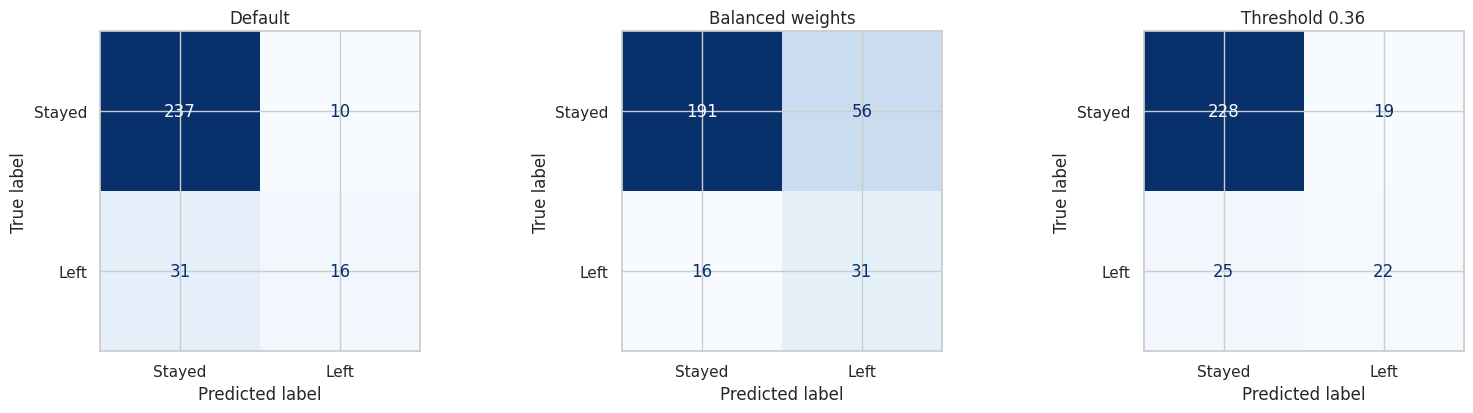

In [11]:
bal = make_model(class_weight="balanced").fit(X_train, y_train)
proba_bal = bal.predict_proba(X_test)[:, 1]

# Threshold chosen on TRAINING data via cross-validated probabilities (no peeking at the test set)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof = cross_val_predict(make_model(), X_train, y_train, cv=cv, method="predict_proba")[:, 1]
grid_t = np.linspace(0.05, 0.9, 86)
best_t = grid_t[np.argmax([f1_score(y_train, oof >= t) for t in grid_t])]
print(f"Threshold maximising cross-validated F1 on train: {best_t:.2f}")

rows = [evaluate(y_test, pred, proba, "Default (thr 0.5)"),
        evaluate(y_test, bal.predict(X_test), proba_bal, "class_weight='balanced' (thr 0.5)"),
        evaluate(y_test, (proba >= best_t).astype(int), proba, f"Threshold moved to {best_t:.2f}")]
imb = pd.DataFrame(rows).set_index("Model"); display(imb)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for a, (t, yh) in zip(ax, [("Default", pred), ("Balanced weights", bal.predict(X_test)), (f"Threshold {best_t:.2f}", (proba >= best_t).astype(int))]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, yh), display_labels=["Stayed", "Left"]).plot(ax=a, cmap="Blues", colorbar=False); a.set_title(t)
plt.tight_layout(); plt.show()

**Takeaway:** both fixes trade precision (more false alarms) for **recall**, while AUC stays about the same (≈ 0.80–0.81), because AUC measures ranking, not the cutoff.
- **Balanced class weights** roughly *double* recall (0.34 → 0.66) but precision falls to ≈ 0.36 and accuracy to ≈ 0.76; F1 barely improves.
- **Moving the threshold to ≈ 0.36** gives the best F1 (≈ 0.50) with a more moderate recall (≈ 0.47) and precision (≈ 0.54).
Which to choose depends on the cost of a missed leaver versus an unnecessary retention intervention.

# PART B – Question 3: Hyperparameter Tuning & Model Optimisation

## 1. Parameters vs hyperparameters
| | **Parameters** | **Hyperparameters** |
|---|---|---|
| What | Internal values **learned from data** during training | Settings chosen **before** training that control the learning process |
| Logistic regression example | Coefficients $\\beta_j$ and intercept | `C` (inverse regularisation strength), `penalty` (L1/L2), `solver`, `max_iter`, `class_weight` |
| Set by | The optimisation algorithm | The practitioner, via manual search, grid/random search, Bayesian optimisation… |
| Evaluated on | Training loss | **Validation / cross-validation** performance (never on the test set) |

Regularisation: smaller `C` = stronger penalty = simpler model (less variance, more bias). **L2** shrinks coefficients; **L1** can set some to exactly zero (feature selection). `solver` decides the optimisation algorithm and which penalties are allowed (`liblinear`: L1/L2; `saga`: L1/L2/elastic-net; `lbfgs`: L2 only).

## 2. Baseline model
Default `LogisticRegression` (C=1, L2, lbfgs), scored with 5-fold stratified CV on the training data plus the held-out test set. **Primary metric: ROC-AUC** (robust to imbalance); recall and F1 are also reported.

In [12]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
t0 = time.time(); base = make_model().fit(X_train, y_train); base_time = time.time() - t0
base_cv = cross_val_predict(make_model(), X_train, y_train, cv=cv, method="predict_proba")[:, 1]
print(f"Baseline CV ROC-AUC (train): {roc_auc_score(y_train, base_cv):.4f}")
res_base = evaluate(y_test, base.predict(X_test), base.predict_proba(X_test)[:, 1], "Baseline (defaults)")
res_base["Fit time (s)"] = base_time; res_base["CV AUC"] = roc_auc_score(y_train, base_cv)
pd.DataFrame([res_base]).set_index("Model")

Baseline CV ROC-AUC (train): 0.8365


,Accuracy,Precision,Recall,F1,AUC,Fit time (s),CV AUC
Model,,,,,,,
Baseline (defaults),0.8605,0.6154,0.3404,0.4384,0.8117,0.0166,0.8365


## 3. GridSearchCV
Exhaustive search over `C`, `penalty`, `solver` (only valid combinations are listed).

In [13]:
pipe = make_model()
param_grid = [
    {"clf__solver": ["liblinear", "saga"], "clf__penalty": ["l1", "l2"], "clf__C": [0.001, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 100]},
    {"clf__solver": ["lbfgs"],              "clf__penalty": ["l2"],       "clf__C": [0.001, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 100]},
]
grid = GridSearchCV(pipe, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, return_train_score=True)
t0 = time.time(); grid.fit(X_train, y_train); grid_time = time.time() - t0
n_combo = sum(np.prod([len(v) for v in g.values()]) for g in param_grid)
print(f"Combinations: {n_combo} x 5 folds = {n_combo*5} fits | wall time {grid_time:.1f}s")
print("Best params:", {k.replace('clf__', ''): v for k, v in grid.best_params_.items()}, "| best CV AUC: %.4f" % grid.best_score_)
gres = pd.DataFrame(grid.cv_results_)
gres[["param_clf__solver", "param_clf__penalty", "param_clf__C", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score").head(10)

Combinations: 45 x 5 folds = 225 fits | wall time 24.0s
Best params: {'C': 1, 'penalty': 'l1', 'solver': 'saga'} | best CV AUC: 0.8391


,param_clf__solver,param_clf__penalty,param_clf__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
21,saga,l1,1.0000,0.8752,0.8391,0.0283,1
20,liblinear,l1,1.0000,0.8745,0.8386,0.0288,2
31,saga,l2,10.0000,0.8802,0.8382,0.0277,3
29,saga,l1,10.0000,0.8802,0.8379,0.0271,4
25,saga,l1,3.0000,0.8784,0.8379,0.0282,5
24,liblinear,l1,3.0000,0.8782,0.8379,0.0289,6
27,saga,l2,3.0000,0.8786,0.8378,0.0290,7
43,lbfgs,l2,10.0000,0.8802,0.8378,0.0279,8
42,lbfgs,l2,3.0000,0.8786,0.8377,0.0290,9
41,lbfgs,l2,1.0000,0.8762,0.8377,0.0303,10


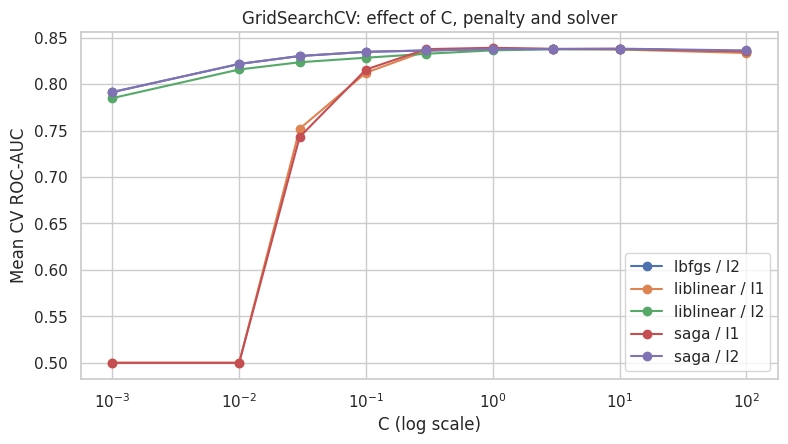

In [14]:
g = gres.assign(C=gres.param_clf__C.astype(float), combo=gres.param_clf__solver.astype(str) + " / " + gres.param_clf__penalty.astype(str))
plt.figure(figsize=(9, 4.5))
for k, d in g.groupby("combo"): d = d.sort_values("C"); plt.plot(d.C, d.mean_test_score, marker="o", label=k)
plt.xscale("log"); plt.xlabel("C (log scale)"); plt.ylabel("Mean CV ROC-AUC"); plt.title("GridSearchCV: effect of C, penalty and solver"); plt.legend(); plt.show()

**Reading the curve:** very small `C` (heavy regularisation) under-fits; performance rises and then plateaus/declines for large `C` as the model starts to over-fit the 1,000-odd training rows. Solvers that optimise the *same* objective (e.g. `liblinear` vs `saga` with the same penalty) give nearly identical scores – `solver` mostly affects speed/convergence, while `C` and `penalty` affect accuracy.

## 4. RandomizedSearchCV
Samples 30 random configurations; `C` is drawn from a **log-uniform** distribution (continuous range 1e-3 … 1e2) instead of a fixed grid.

In [15]:
param_dist = {"clf__C": loguniform(1e-3, 1e2), "clf__penalty": ["l1", "l2"], "clf__solver": ["liblinear", "saga"]}
rand = RandomizedSearchCV(pipe, param_dist, n_iter=30, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=RANDOM_STATE, return_train_score=True)
t0 = time.time(); rand.fit(X_train, y_train); rand_time = time.time() - t0
print(f"30 candidates x 5 folds = 150 fits | wall time {rand_time:.1f}s")
print("Best params:", {k.replace('clf__', ''): (round(v, 4) if isinstance(v, float) else v) for k, v in rand.best_params_.items()}, "| best CV AUC: %.4f" % rand.best_score_)
pd.DataFrame(rand.cv_results_)[["param_clf__solver", "param_clf__penalty", "param_clf__C", "mean_test_score", "rank_test_score"]].sort_values("rank_test_score").head(5)

30 candidates x 5 folds = 150 fits | wall time 18.4s
Best params: {'C': np.float64(0.9164), 'penalty': 'l1', 'solver': 'liblinear'} | best CV AUC: 0.8391


,param_clf__solver,param_clf__penalty,param_clf__C,mean_test_score,rank_test_score
14,liblinear,l1,0.9164,0.8391,1
15,liblinear,l1,1.0907,0.8384,2
19,saga,l1,2.6373,0.8383,3
10,saga,l2,1.1462,0.8379,4
6,saga,l2,14.5282,0.8378,5


## 5. Performance before vs after tuning (held-out test set)

,Accuracy,Precision,Recall,F1,AUC,CV AUC,Search time (s),Model fits
Model,,,,,,,,
Baseline (defaults),0.8605,0.6154,0.3404,0.4384,0.8117,0.8365,0.0166,5
GridSearchCV best,0.8639,0.6296,0.3617,0.4595,0.8101,0.8391,24.0410,225
RandomizedSearchCV best,0.8639,0.6296,0.3617,0.4595,0.8079,0.8391,18.4057,150


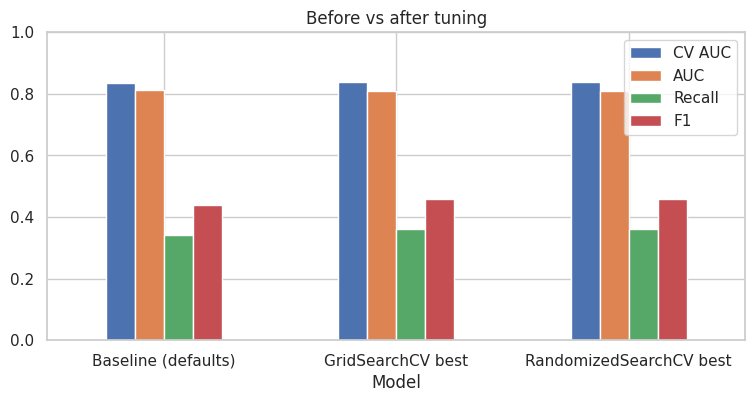

In [16]:
rows = []
for name, m, t, ncv in [("Baseline (defaults)", base, base_time, 5), ("GridSearchCV best", grid.best_estimator_, grid_time, n_combo * 5), ("RandomizedSearchCV best", rand.best_estimator_, rand_time, 150)]:
    r = evaluate(y_test, m.predict(X_test), m.predict_proba(X_test)[:, 1], name)
    r["CV AUC"] = {"Baseline (defaults)": res_base["CV AUC"], "GridSearchCV best": grid.best_score_, "RandomizedSearchCV best": rand.best_score_}[name]
    r["Search time (s)"] = t; r["Model fits"] = ncv; rows.append(r)
comp = pd.DataFrame(rows).set_index("Model"); display(comp)
comp[["CV AUC", "AUC", "Recall", "F1"]].plot.bar(figsize=(9, 4), rot=0, title="Before vs after tuning"); plt.ylim(0, 1); plt.show()

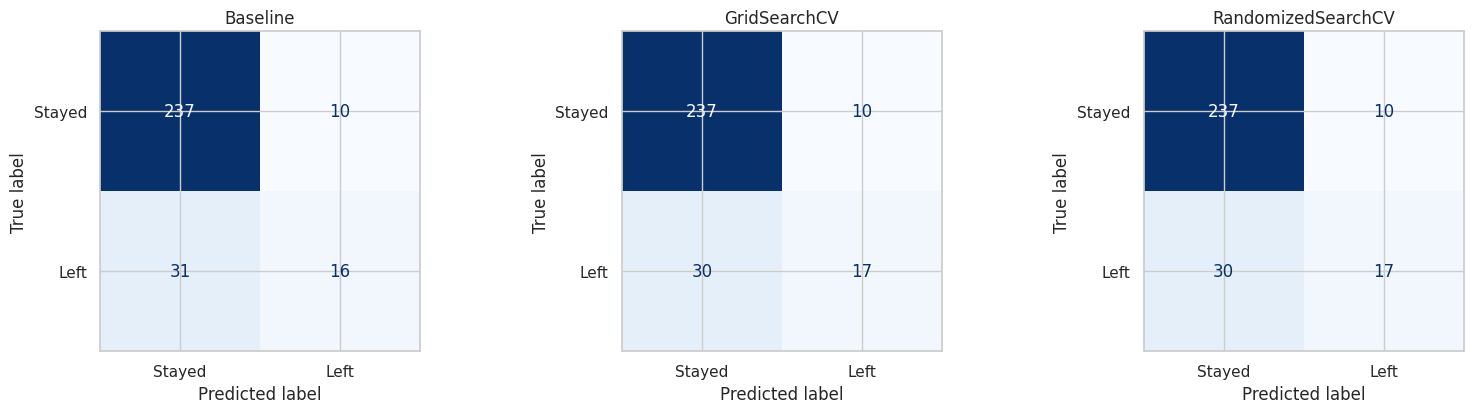

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for a, (n, m) in zip(ax, [("Baseline", base), ("GridSearchCV", grid.best_estimator_), ("RandomizedSearchCV", rand.best_estimator_)]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, m.predict(X_test)), display_labels=["Stayed", "Left"]).plot(ax=a, cmap="Blues", colorbar=False); a.set_title(n)
plt.tight_layout(); plt.show()

**Findings**
- Both searches selected an **L1 penalty with C ≈ 1** (Grid: `saga`, C = 1; Random: `liblinear`, C ≈ 0.92). So the regularisation *strength* is essentially the default; the gain comes from L1 switching some weak predictors off.
- The improvement is **tiny**: CV-AUC goes from 0.8365 to 0.8391 (+0.003), far smaller than the fold-to-fold standard deviation (≈ 0.03). On the held-out test set AUC is actually marginally *lower* (0.812 → 0.810 / 0.808), and the recall/precision gain (0.34 → 0.36 recall) is **one additional leaver caught out of 47**. With 294 test rows these differences are noise, so the honest conclusion is that the defaults were already near-optimal for this model and dataset.
- Random search reaches the **same best CV-AUC (0.8391) as the grid** with fewer fits (150 vs 225) and less time (≈ 19 s vs ≈ 25 s), because performance is flat over a wide range of `C`.
- Improving **recall/F1** would come from the *threshold / class-weight* choices (Part A §7), not from tuning `C`. If recall matters, add `class_weight` to the search space and/or use `scoring="f1"` or `"recall"`.

## 6. Trade-offs: computational cost vs model performance
| Aspect | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| Coverage | Exhaustive and reproducible over the listed values | Random sample; can explore continuous ranges (e.g. `C` log-uniform) |
| Cost | Grows **multiplicatively** with each hyper-parameter (n₁×n₂×n₃ × k folds) | **Fixed budget** (`n_iter` × k folds), independent of space size |
| Risk | Can miss values that fall between grid points | May miss the exact optimum, but near-optimal is usually found |
| Best when | Few hyper-parameters / small space / cheap model | Many hyper-parameters, big data, expensive models |

**Practical points**
- Cost = (#candidates) × (#CV folds) × (time per fit). Here a fit takes milliseconds, so either search is cheap; for deep models or millions of rows it would not be.
- Returns **diminish**: the first few configurations give most of the benefit; exhaustively refining the grid buys very little extra and raises the risk of **over-fitting the validation folds** (selection bias). Always report final performance on an untouched test set.
- Reduce cost with coarser-to-finer searches (random first, then a small grid around the best region), fewer folds, `n_jobs=-1`, successive halving (`HalvingGridSearchCV`) or Bayesian optimisation (e.g. Optuna).
- Choose the scoring metric that matches the business goal (AUC for ranking risk, recall/F1 for catching leavers).
- Since performance gain from tuning here is marginal, the **simplest, cheapest** option that performs comparably (random search, or even the baseline) is often the best engineering choice.

## Overall conclusions
1. Logistic Regression is an appropriate, interpretable model for the binary attrition problem; with proper preprocessing it achieves a good AUC.
2. Odds ratios point HR to actionable drivers: **frequent business travel, overtime, specific roles (lab technicians, sales reps), being single, low satisfaction/work-life balance, stalled promotions and long commutes**.
3. Class imbalance hides poor minority-class recall (≈ 0.34) behind ≈ 86% accuracy – class weights (recall ≈ 0.66) or a lower threshold (best F1 ≈ 0.50) fix this, judged by recall, F1 and AUC.
4. Hyper-parameter tuning (Grid and Random search) gives a negligible gain for logistic regression (CV-AUC +0.003, no real test improvement); random search matched the grid with fewer fits.